# TP5 , Acquisition et Nettoyage des Données : Titanic

**Réalisé par:**  
Jean-Daniel KITIHOUN  
Vaneck Duramel DAGAR TIYO 

## 1. Mise en place

### 1.1 Installations

In [23]:
# %pip install pandas numpy scikit-learn seaborn matplotlib missingno rapidfuzz joblib

### 1.2 Imports

In [2]:
import hashlib
import json
import re
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import seaborn as sns

from rapidfuzz import fuzz, process
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import IsolationForest
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer, SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
np.random.seed(42)

### 1.3 Chargement du dataset

In [3]:
df = sns.load_dataset("titanic")
print(f"Dataset : {df.shape[0]} passagers, {df.shape[1]} colonnes")

# Sauvegarde d'une copie originale (à ne JAMAIS modifier)
df_brut = df.copy()
df.head()

Dataset : 891 passagers, 15 colonnes


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Diagnostic qualité

### 2.1 Profilage rapide

**Question 1.** Premier tour d'horizon du dataset.

In [28]:
print("Types de colonnes :")
print(df.dtypes)
print()
print("Statistiques descriptives :")
print(df.describe(include="all").T)
print()
print("Manquants (%) :")
print((df.isna().mean() * 100).round(1).sort_values(ascending=False))

Types de colonnes :
survived                  int64
pclass                    int64
sex                         str
age                     float64
sibsp                     int64
parch                     int64
fare                    float64
embarked                    str
class                  category
who                         str
adult_male                 bool
deck                   category
embark_town                 str
alive                       str
alone                      bool
out_fare_par_classe        bool
log_fare                float64
dtype: object

Statistiques descriptives :
                     count unique          top freq       mean        std   min       25%       50%       75%  \
survived             891.0    NaN          NaN  NaN   0.383838   0.486592   0.0       0.0       0.0       1.0   
pclass               891.0    NaN          NaN  NaN   2.308642   0.836071   1.0       2.0       3.0       3.0   
sex                    891      2         male  577   

1. Deux colonnes ont le dtype `category` : `class` et `deck`. Cinq autres colonnes ont le dtype `str` (chaînes de caractères) : `sex`, `embarked`, `who`, `embark_town`, `alive`. Ces sept colonnes constituent les variables catégorielles du dataset. Les colonnes numériques sont `survived`, `pclass`, `age`, `sibsp`, `parch` et `fare`. Les indicateurs booléens `adult_male` et `alone` forment une troisième catégorie à part.

2. Les trois colonnes les plus incomplètes sont `deck` (≈ 77.2 % de manquants), `age` (≈ 19,9 %) et `embarked` / `embark_town` (≈ 0,2 %).

3. La colonne `fare` présente un écart-type d'environ 49,7 GBP pour une médiane proche de 14,5 GBP, signe d'une distribution fortement asymétrique tirée vers le haut par quelques billets de 1ʳᵉ classe extrêmement chers.

### 2.2 Visualisation des manquants

**Question 2.** Visualisation des patterns de manquants.

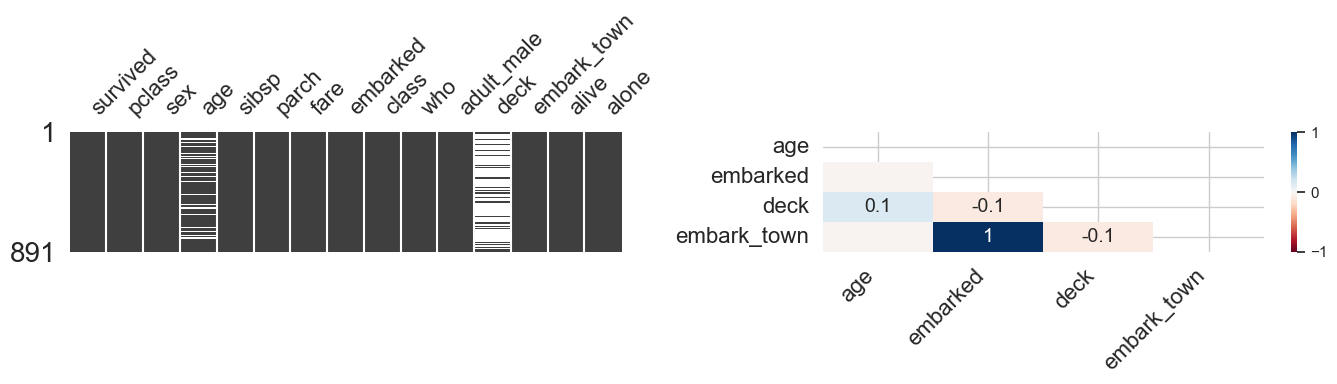

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
msno.matrix(df, ax=axes[0])
msno.heatmap(df, ax=axes[1])
plt.tight_layout()
plt.show()

La heatmap montre une corrélation parfaite (≈ 1) entre `embarked` et `embark_town` : ces deux colonnes encodent la même information et manquent toujours ensemble. Aucune autre paire ne présente de co-absence notable.

### 2.3 Les 4 dimensions de qualité

**Question 3.** Quatre indicateurs synthétiques.

In [6]:
qualite = {
    "completude_globale": 1 - df.isna().mean().mean(),
    "lignes_completes_pct": (~df.isna().any(axis=1)).mean(),
    "doublons_exacts": int(df.duplicated().sum()),
    "doublons_sur_id": int(df.duplicated(subset=["sex", "age", "fare", "pclass"]).sum()),
}
for k, v in qualite.items():
    print(f"  {k:25s}: {v}")

  completude_globale       : 0.9349794238683128
  lignes_completes_pct     : 0.20426487093153758
  doublons_exacts          : 107
  doublons_sur_id          : 140


1. La complétude globale est d'environ 93,5 % : seules trois colonnes concentrent la quasi-totalité des manquants. En revanche, seulement 20 % des passagers ont une fiche entièrement renseignée, car la présence de `deck` parmi les variables tire ce taux vers le bas, cette colonne étant absente pour les trois quarts des lignes.

2. On dénombre 107 doublons exacts. Sur la combinaison `(sex, age, fare, pclass)`, 140 lignes sont concernées.

3. Ces doublons et profils similaires correspondent à des passagers voyageant ensemble (familles, billets groupés au même tarif). Il est peu probable qu'il s'agisse du même individu enregistré deux fois : les billets groupés et les membres d'une même famille peuvent parfaitement partager les mêmes valeurs sur ces quatre champs. On les conserve donc, mais leur présence mérite d'être notée dans le journal d'audit.

## 3. Valeurs manquantes

### 3.1 Identifier le mécanisme de manque

**Question 4.** La colonne `age` est manquante pour 20 % des passagers. Aléatoire ou lié à la classe ?

In [7]:
# Taux de manquants sur age par classe
print("Manquants 'age' par pclass (%) :")
print(df.groupby("pclass")["age"].apply(lambda x: x.isna().mean() * 100).round(1))
print()
# Test plus fin : par classe et par sexe
print("Manquants 'age' par pclass × sex (%) :")
print(df.groupby(["pclass", "sex"])["age"].apply(lambda x: x.isna().mean() * 100).round(1))

Manquants 'age' par pclass (%) :
pclass
1    13.9
2     6.0
3    27.7
Name: age, dtype: float64

Manquants 'age' par pclass × sex (%) :
pclass  sex   
1       female     9.6
        male      17.2
2       female     2.6
        male       8.3
3       female    29.2
        male      27.1
Name: age, dtype: float64


1. Le taux de manquants sur `age` n'est pas homogène. La 2ᵉ classe présente le moins de valeurs absentes (6,0 %), suivie de la 1ʳᵉ (13,9 %) ; la 3ᵉ classe concentre à elle seule 27,7 % de manquants. Une dépendance au sexe s'observe également, particulièrement marquée en 1ʳᵉ classe (9,6 % pour les femmes contre 17,2 % pour les hommes).

2. Comme l'absence d'âge dépend de variables observées (`pclass`, `sex`) et non de la valeur de l'âge lui-même, c'est un mécanisme MAR (*Missing At Random*). Historiquement, les listes d'embarquement de 3ᵉ classe étaient tenues moins rigoureusement que celles des classes supérieures.

3. Une imputation conditionnelle, par exemple la médiane par groupe `pclass × sex` ou le KNN multivarié, sera par conséquent plus juste qu'une médiane globale, qui ignorerait cette structure et écraserait la dispersion intra-groupe.

### 3.2 Stratégies d'imputation

**Question 5.** Comparaison de trois stratégies d'imputation pour `age`.

In [8]:
# Stratégie A : médiane globale
df_a = df.copy()
df_a["age"] = df_a["age"].fillna(df_a["age"].median())

# Stratégie B : médiane par groupe (classe × sexe)
df_b = df.copy()
df_b["age"] = df_b.groupby(["pclass", "sex"])["age"].transform(
    lambda x: x.fillna(x.median())
)

# Stratégie C : KNN (utilise plusieurs colonnes pour prédire)
df_c = df.copy()
cols_num = ["age", "fare", "sibsp", "parch", "pclass"]
knn = KNNImputer(n_neighbors=5)
df_c[cols_num] = knn.fit_transform(df_c[cols_num])

for nom, dfx in [("A_median_globale", df_a), ("B_median_groupe", df_b), ("C_KNN", df_c)]:
    s = dfx["age"]
    print(f"{nom:20s} mean={s.mean():.1f} std={s.std():.1f} median={s.median():.1f}")

print(f"\nOriginal (avec NaN)  mean={df['age'].mean():.1f} std={df['age'].std():.1f} median={df['age'].median():.1f}")

A_median_globale     mean=29.4 std=13.0 median=28.0
B_median_groupe      mean=29.1 std=13.3 median=26.0
C_KNN                mean=29.9 std=13.4 median=29.0

Original (avec NaN)  mean=29.7 std=14.5 median=28.0


1. La stratégie A (médiane globale) est celle qui réduit le plus artificiellement la variance : remplacer tous les manquants par une constante unique comprime la distribution de l'âge. Les stratégies B (médiane par groupe) et C (KNN) préservent mieux l'écart-type original. C'est le critère décisif, car un dataset dont la dispersion est artificiellement comprimée biaise vers le bas la volatilité estimée par les modèles en aval.

2. Le KNN produit une moyenne légèrement différente de l'original, parce qu'il choisit des voisins multidimensionnels plutôt qu'une statistique de tendance centrale. Cela ne le disqualifie pas : la moyenne originale est calculée sur les seules valeurs présentes, qui surreprésentent les classes supérieures (mieux renseignées) et donc des âges moyens plus élevés ; le KNN corrige partiellement cette asymétrie.

3. Pour un livrable simple et interprétable, la médiane par groupe (B) est le meilleur compromis : elle préserve la dispersion, reste explicable à un non-technicien et ne dépend pas du choix de `n_neighbors`. Le pipeline scikit-learn final utilise le KNN, qui est l'équivalent multivarié et reste reproductible sur de nouvelles données.

### 3.3 Cas `deck` , 77 % de manquants

**Question 6.** La colonne `deck` est manquante pour 77 % des passagers.

In [9]:
print("Manquants 'deck' par pclass (%) :")
print(df.groupby("pclass")["deck"].apply(lambda x: x.isna().mean() * 100).round(1))

Manquants 'deck' par pclass (%) :
pclass
1    19.0
2    91.3
3    97.6
Name: deck, dtype: float64


1. Le manque est très fortement structuré par la classe : relativement limité en 1ʳᵉ classe (19,0 %), il monte à 91,3 % en 2ᵉ classe et atteint 97,6 % en 3ᵉ.

2. Les passagers de 2ᵉ et 3ᵉ classe n'avaient généralement pas de numéro de cabine individuel attribué nominativement dans les registres. La valeur manquante ne traduit donc pas un oubli de saisie : elle reflète l'absence d'attribution réelle. C'est un mécanisme MNAR, dans lequel la manquance est liée à la valeur elle-même, en l'occurrence l'inexistence d'une cabine individuelle pour la grande majorité de ces passagers.

3. Avec 77 % de manquants globaux concentrés sur un tel mécanisme, toute imputation introduirait un biais arbitraire en inventant de l'information qui n'a jamais existé. Décision : supprimer la colonne `deck` du dataset livré.

## 4. Outliers

### 4.1 Détection univariée , IQR

**Question 7.** Détection des outliers de `fare` (prix du billet).

Outliers fare (k=1.5) : 116 (13.0 %)
Max fare : 512 GBP
Q3 + 1.5 IQR : 66 GBP


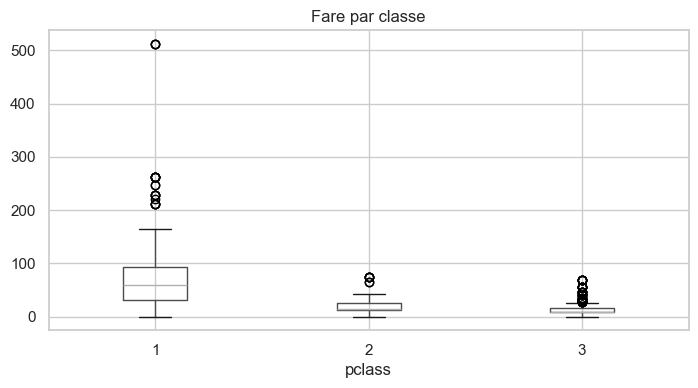

In [10]:
def outliers_iqr(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (s < q1 - k * iqr) | (s > q3 + k * iqr)

mask = outliers_iqr(df["fare"])
print(f"Outliers fare (k=1.5) : {mask.sum()} ({mask.mean() * 100:.1f} %)")
print(f"Max fare : {df['fare'].max():.0f} GBP")
q1, q3 = df['fare'].quantile([0.25, 0.75])
print(f"Q3 + 1.5 IQR : {q3 + 1.5 * (q3 - q1):.0f} GBP")

df.boxplot(column="fare", by="pclass", figsize=(8, 4))
plt.suptitle("")
plt.title("Fare par classe")
plt.show()

1. Le critère IQR global identifie 116 passagers (13,0 %) comme ayant un prix de billet aberrant, soit tout billet dépassant 65,6 GBP.

2. Le boxplot confirme que ces outliers se concentrent presque entièrement en 1ʳᵉ classe (104 sur 116). La détection globale, aveugle à la structure par classe, signale toute la queue droite de la distribution de 1ʳᵉ classe comme aberrante.

3. Ces billets très chers correspondent à des passagers réellement présents. Les supprimer reviendrait à effacer un sous-segment clientèle valide. La décision est de les conserver, en atténuant leur poids dans les calculs via une transformation logarithmique et un RobustScaler insensible aux extrêmes.

### 4.2 IQR par groupe

**Question 8.** Détection IQR par classe pour corriger l'effet de structure.

In [11]:
df["out_fare_par_classe"] = df.groupby("pclass")["fare"].transform(outliers_iqr).astype(bool)
print("Outliers fare par classe :")
print(df.groupby("pclass")["out_fare_par_classe"].sum())
print(f"Total : {int(df['out_fare_par_classe'].sum())}")
print(f"Comparaison : global={int(mask.sum())} vs par classe={int(df['out_fare_par_classe'].sum())}")

Outliers fare par classe :
pclass
1    20
2     7
3    52
Name: out_fare_par_classe, dtype: int64
Total : 79
Comparaison : global=116 vs par classe=79


La détection par classe identifie 79 outliers contre 116 pour la méthode globale. La redistribution est surtout frappante : la 1ʳᵉ classe ne compte plus que 20 outliers (contre 104), tandis que la 3ᵉ classe en présente désormais 52. Ce sont donc des prix atypiques au sein de chaque sous-population qui sont détectés, et non plus simplement les billets chers de 1ʳᵉ classe. Cette approche est plus pertinente parce qu'elle compare chaque passager à des pairs comparables, plutôt qu'à une référence agrégée qui mélange des distributions hétérogènes.

### 4.3 Détection multivariée , Isolation Forest

**Question 9.** Détection des profils anormaux sur plusieurs variables simultanément.

In [12]:
cols = ["age", "fare", "sibsp", "parch", "pclass"]
X = df[cols].dropna()

iso = IsolationForest(contamination=0.05, random_state=42, n_estimators=100)
preds = iso.fit_predict(X)

X = X.copy()
X["anomalie"] = preds == -1
X["score"] = iso.decision_function(X.drop(columns=["anomalie"]))

print(f"Anomalies : {int(X['anomalie'].sum())} ({X['anomalie'].mean() * 100:.1f} %)")
print("\n10 profils les plus anormaux :")
print(X.nsmallest(10, "score"))

Anomalies : 36 (5.0 %)

10 profils les plus anormaux :
      age      fare  sibsp  parch  pclass  anomalie     score
438  64.0  263.0000      1      4       1      True -0.108205
27   19.0  263.0000      3      2       1      True -0.099055
88   23.0  263.0000      3      2       1      True -0.094162
341  24.0  263.0000      3      2       1      True -0.093595
678  43.0   46.9000      1      6       3      True -0.077568
638  41.0   39.6875      0      5       3      True -0.071896
311  18.0  262.3750      2      2       1      True -0.070692
679  36.0  512.3292      0      1       1      True -0.066983
742  21.0  262.3750      2      2       1      True -0.066064
885  39.0   29.1250      0      5       3      True -0.062599


1. Deux types de profils dominent parmi les dix plus anormaux. D'un côté, plusieurs passagers de 1ʳᵉ classe voyageant en famille et ayant payé un tarif de 263 GBP (voire 512 GBP), très au-dessus de la norme même pour cette classe. De l'autre, des passagers de 3ᵉ classe accompagnés de familles très nombreuses (5 à 6 enfants ou parents), avec des tarifs groupés que l'algorithme considère atypiques compte tenu du profil multidimensionnel.

2. Le score de `decision_function` mesure la normalité d'un point dans la forêt : positif pour une observation jugée normale, négatif pour une anomalie. Plus il est bas (très négatif), plus le point est isolé rapidement par les arbres, donc plus il est suspect.

3. Le paramètre `contamination=0.05` indique au modèle qu'on s'attend à environ 5 % d'anomalies : il fixe le seuil de décision sur les 5 % de scores les plus faibles. Avec `contamination=0.20`, le modèle classerait 20 % de l'échantillon en anomalies, signalant comme aberrants de nombreux profils parfaitement normaux.

## 5. Doublons et déduplication floue

### 5.1 Doublons exacts

**Question 10.** Y a-t-il des passagers en double ?

In [13]:
print(f"Doublons exacts : {df.duplicated().sum()}")
print(
    "Sur (sex, age, fare, pclass, embarked) :",
    df.duplicated(subset=['sex', 'age', 'fare', 'pclass', 'embarked']).sum(),
)
mask_dup = df.duplicated(
    subset=["sex", "age", "fare", "pclass", "embarked"], keep=False
)
print("\nLignes concernées :")
print(df[mask_dup].sort_values(["sex", "age", "fare", "pclass"]).head(10))

Doublons exacts : 107
Sur (sex, age, fare, pclass, embarked) : 137

Lignes concernées :
     survived  pclass     sex    age  sibsp  parch     fare embarked   class    who  adult_male deck  embark_town  \
469         1       3  female   0.75      2      1  19.2583        C   Third  child       False  NaN    Cherbourg   
644         1       3  female   0.75      2      1  19.2583        C   Third  child       False  NaN    Cherbourg   
427         1       2  female  19.00      0      0  26.0000        S  Second  woman       False  NaN  Southampton   
546         1       2  female  19.00      1      0  26.0000        S  Second  woman       False  NaN  Southampton   
199         0       2  female  24.00      0      0  13.0000        S  Second  woman       False  NaN  Southampton   
345         1       2  female  24.00      0      0  13.0000        S  Second  woman       False    F  Southampton   
369         1       1  female  24.00      0      0  69.3000        C   First  woman       Fal

On dénombre 107 lignes en doublon strict (toutes colonnes identiques) et 137 doublons supplémentaires sur la combinaison `(sex, age, fare, pclass, embarked)`. Dans un registre de passagers, deux entrées rigoureusement identiques sur tous les champs , y compris `survived` , sont peu vraisemblables pour des individus distincts ; il s'agit probablement d'erreurs de saisie ou de doublons d'importation. Pour la combinaison partielle, le contexte historique (familles nombreuses voyageant ensemble avec le même billet groupé) rend en revanche l'hypothèse de passagers distincts plausible. En pratique, on supprimera les doublons exacts stricts avant toute modélisation.

### 5.2 Doublons flous sur le port d'embarquement

**Question 11.** Simulation d'une saisie sale et résolution avec RapidFuzz.

In [14]:
# Simulation d'une saisie sale (typos, casse, abréviations)
np.random.seed(42)
saisies_sales = np.random.choice(
    [
        "Southampton", "southamton", "SOUTHAMPTON", "S. Hampton",
        "Cherbourg", "cherbourg", "Cherb.",
        "Queenstown", "Queens town", "QSTOWN",
    ],
    size=200,
)
df_sale = pd.DataFrame({"port": saisies_sales})
print(f"Valeurs uniques : {df_sale['port'].nunique()}")
print(df_sale["port"].value_counts())

Valeurs uniques : 10
port
Cherb.         26
Queenstown     23
Southampton    23
Cherbourg      20
Queens town    20
QSTOWN         19
SOUTHAMPTON    19
S. Hampton     18
southamton     17
cherbourg      15
Name: count, dtype: int64


In [15]:
# Liste de référence (3 ports officiels)
ports_officiels = ["Southampton", "Cherbourg", "Queenstown"]


def resoudre(nom, ref, seuil=70):
    if pd.isna(nom):
        return None
    match = process.extractOne(str(nom), ref, scorer=fuzz.ratio)
    return match[0] if match and match[1] >= seuil else None


df_sale["port_canon_70"] = df_sale["port"].apply(lambda x: resoudre(x, ports_officiels, 70))
df_sale["port_canon_50"] = df_sale["port"].apply(lambda x: resoudre(x, ports_officiels, 50))

print("Mapping (seuil = 70) :")
print(df_sale.groupby("port")["port_canon_70"].first())
print("\nRépartition seuil 70 :")
print(df_sale["port_canon_70"].value_counts(dropna=False))
print("\nRépartition seuil 50 :")
print(df_sale["port_canon_50"].value_counts(dropna=False))

Mapping (seuil = 70) :
port
Cherb.                 NaN
Cherbourg        Cherbourg
QSTOWN                 NaN
Queens town     Queenstown
Queenstown      Queenstown
S. Hampton             NaN
SOUTHAMPTON            NaN
Southampton    Southampton
cherbourg        Cherbourg
southamton     Southampton
Name: port_canon_70, dtype: str

Répartition seuil 70 :
port_canon_70
NaN            82
Queenstown     43
Southampton    40
Cherbourg      35
Name: count, dtype: int64

Répartition seuil 50 :
port_canon_50
Cherbourg      61
Southampton    58
Queenstown     43
NaN            38
Name: count, dtype: int64


1. Avec un seuil de 70, six variantes sur dix sont résolues : `southamton`, `cherbourg`, `Queens town`, `Queenstown`, `Cherbourg` et `Southampton`. Les quatre autres (`SOUTHAMPTON`, `Cherb.`, `S. Hampton` et `QSTOWN`) restent à `None`. Cela représente 82 lignes non résolues sur 200, car `fuzz.ratio` est sensible à la casse et aux abréviations importantes.

2. Ces quatre variantes non résolues illustrent deux types de problèmes distincts : les abréviations (`Cherb.`, `S. Hampton`) dont la similarité de caractères est trop faible, et les chaînes entièrement en majuscules (`SOUTHAMPTON`, `QSTOWN`) pour lesquelles `fuzz.ratio`, sensible à la casse, donne un score inférieur au seuil même si la correspondance semble évidente. C'est volontaire, car on préfère renvoyer une absence à un appariement douteux qui contaminerait les données.

3. En abaissant le seuil à 50, `Cherb.` et `S. Hampton` sont également résolues, ce qui réduit les `None` à 38 (uniquement `SOUTHAMPTON` et `QSTOWN` restent non résolus même à ce seuil bas). Le risque est d'accepter des correspondances de moindre qualité et d'apparier par erreur des chaînes qui ne désignent pas la même entité. Le choix du seuil est un compromis classique entre rappel et précision.

## 6. Transformations

### 6.1 Encodage des catégorielles

**Question 12.** Encodage One-Hot de `sex` et `embarked`.

In [16]:
# pclass est déjà ordonnée (1 < 2 < 3) -> on peut la laisser numérique
# sex et embarked -> One-Hot
df_enc = pd.get_dummies(df, columns=["sex", "embarked"], drop_first=True)
print(f"Avant : {df.shape}, après OneHot : {df_enc.shape}")
print(
    "Nouvelles colonnes :",
    [c for c in df_enc.columns if c.startswith(('sex_', 'embarked_'))],
)

Avant : (891, 16), après OneHot : (891, 17)
Nouvelles colonnes : ['sex_male', 'embarked_Q', 'embarked_S']


1. `drop_first=True` supprime la première modalité de chaque variable encodée pour éviter la multicollinéarité parfaite (*dummy variable trap*) : les colonnes one-hot d'une même variable somment toujours à 1, ce qui les rend linéairement dépendantes de la constante du modèle, rend la matrice de design singulière et empêche l'estimation des coefficients en régression linéaire.

2. `pclass` reste numérique car la variable est ordinale (1 < 2 < 3) et le coût d'un billet est croissant entre les classes. L'encoder en One-Hot permettrait de capturer un effet non monotone, mais on perdrait l'information d'ordre et on ajouterait des colonnes superflues. `sex` et `embarked`, en revanche, sont nominales, sans relation d'ordre naturelle, et doivent donc être encodées en One-Hot.

### 6.2 Transformation du `fare`

**Question 13.** Comparaison `fare` brut vs `log(1 + fare)`.

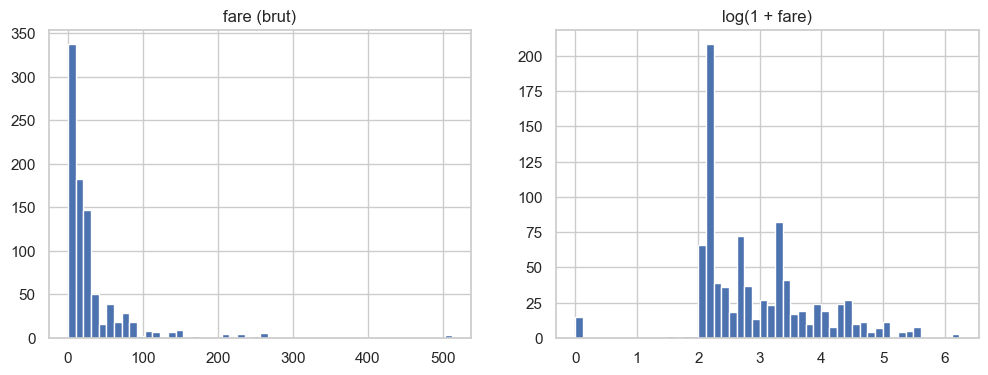

Skewness brut : 4.79
Skewness log  : 0.39


In [17]:
df["log_fare"] = np.log1p(df["fare"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["fare"].hist(bins=50, ax=axes[0])
axes[0].set_title("fare (brut)")
df["log_fare"].hist(bins=50, ax=axes[1])
axes[1].set_title("log(1 + fare)")
plt.show()

print(f"Skewness brut : {df['fare'].skew():.2f}")
print(f"Skewness log  : {df['log_fare'].skew():.2f}")

La transformation `log(1 + fare)` rapproche nettement la distribution d'une cloche
quasi-symétrique : le coefficient d'asymétrie passe d'environ +4,8 à environ +0,4. C'est utile
pour un modèle de régression parce que ses hypothèses (linéarité de l'effet, homoscédasticité,
quasi-normalité des résidus) sont mieux respectées sur une variable peu étalée et peu
influencée par les valeurs extrêmes ; les coefficients estimés deviennent plus stables et
interprétables comme des élasticités.

## 7. Pipeline reproductible

### 7.1 Construction du pipeline

**Question 14.** Assemblage du nettoyage dans un `Pipeline` scikit-learn.

In [18]:
cols_num = ["age", "fare", "sibsp", "parch"]
cols_cat = ["sex", "embarked", "pclass"]

preproc_num = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", RobustScaler()),
])

preproc_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocesseur = ColumnTransformer([
    ("num", preproc_num, cols_num),
    ("cat", preproc_cat, cols_cat),
])

# Application sur tout le dataset (en pratique : split train/test d'abord)
X = df.drop(
    columns=["survived", "alive", "deck", "alone", "class", "who", "adult_male", "embark_town"],
    errors="ignore",
)
y = df["survived"]
X_clean = preprocesseur.fit_transform(X)
print(f"Avant : {X.shape}, après pipeline : {X_clean.shape}")

Avant : (891, 9), après pipeline : (891, 12)


1. L'imputeur doit précéder le scaler parce que ce dernier calcule ses statistiques (médiane, IQR pour `RobustScaler`) à partir des valeurs présentes. Si on standardise d'abord, les `NaN` restent `NaN` et les statistiques du scaler deviennent biaisées ou la transformation échoue.

2. Séparer les transformations numériques et catégorielles dans un `ColumnTransformer` permet d'aiguiller chaque sous-pipeline vers le bon sous-ensemble de colonnes : on ne standardise pas un port d'embarquement et on n'encode pas un âge en One-Hot. Les sorties sont ensuite concaténées en une seule matrice prête pour le modèle.

3. En pratique réelle, on ajuste (`fit`) le pipeline uniquement sur `X_train`, puis on applique (`transform`) sur le test. Ajuster sur tout `X`, y compris le test, ferait intégrer aux statistiques (médianes, voisins KNN, modes, structure One-Hot) de l'information du jeu de test, ce qu'on appelle data leakage, et cela surestime artificiellement les performances du modèle. Le TP ne demande pas de split, donc on `fit_transform` sur tout, mais en production cette règle est incontournable.

### 7.2 Sérialisation et audit

**Question 15.** Sauvegarde du pipeline et des métadonnées.

In [19]:
# 1. Sérialiser le pipeline (réutilisable sur de nouvelles données)
joblib.dump(preprocesseur, "preprocessor.pkl")

# 2. Audit : métadonnées du nettoyage
audit = {
    "lignes_initiales": int(len(df_brut)),
    "lignes_finales": int(X_clean.shape[0]),
    "colonnes_finales": int(X_clean.shape[1]),
    "manquants_avant": {k: int(v) for k, v in df_brut.isna().sum().to_dict().items()},
    "imputer_strategy": "KNN k=5 sur numériques, mode sur catégorielles",
    "scaler": "RobustScaler",
    "colonnes_supprimees": ["deck", "alive", "alone", "class", "who", "adult_male", "embark_town"],
    "hash_brut": hashlib.md5(pd.util.hash_pandas_object(df_brut).values).hexdigest(),
}
with open("audit.json", "w") as f:
    json.dump(audit, f, indent=2, default=str)

# 3. Sauvegarder le dataset nettoyé
df_propre = df.copy()
df_propre["age"] = df.groupby(["pclass", "sex"])["age"].transform(
    lambda x: x.fillna(x.median())
)
df_propre["embarked"] = df_propre["embarked"].fillna(df_propre["embarked"].mode()[0])
df_propre = df_propre.drop(
    columns=["deck", "alive", "alone", "class", "who", "adult_male", "embark_town", "out_fare_par_classe", "log_fare"],
    errors="ignore",
)
df_propre.to_parquet("titanic_clean.parquet", index=False)

print("Sauvegardes : preprocessor.pkl, audit.json, titanic_clean.parquet")
audit

Sauvegardes : preprocessor.pkl, audit.json, titanic_clean.parquet


{'lignes_initiales': 891,
 'lignes_finales': 891,
 'colonnes_finales': 12,
 'manquants_avant': {'survived': 0,
  'pclass': 0,
  'sex': 0,
  'age': 177,
  'sibsp': 0,
  'parch': 0,
  'fare': 0,
  'embarked': 2,
  'class': 0,
  'who': 0,
  'adult_male': 0,
  'deck': 688,
  'embark_town': 2,
  'alive': 0,
  'alone': 0},
 'imputer_strategy': 'KNN k=5 sur numériques, mode sur catégorielles',
 'scaler': 'RobustScaler',
 'colonnes_supprimees': ['deck',
  'alive',
  'alone',
  'class',
  'who',
  'adult_male',
  'embark_town'],
 'hash_brut': 'abceec38c991d784d7aea33ca4760893'}

1. Sérialiser le pipeline avec joblib garantit la reproductibilité : les mêmes médianes apprises, les mêmes catégories et les mêmes échelles sont figées dans le fichier. On peut ainsi déployer le pipeline directement sur de nouvelles données sans dupliquer la logique d'entraînement, et comparer deux versions du modèle en sachant exactement quelle transformation a été appliquée.

2. Le hash du dataset brut fournit une empreinte unique des données sources. Si l'équipe ré-exécute le notebook plusieurs mois plus tard et que le hash a changé, cela signale qu'un fichier source a été modifié entre-temps (ligne corrigée, ré-export depuis la base). On évite ainsi de comparer deux modèles entraînés sur des données différentes en croyant les comparer sur les mêmes.

3. Conserver `df_brut` intact permet à tout moment de comparer l'état avant et après nettoyage, de justifier chaque transformation et de reproduire l'analyse depuis zéro si une décision de nettoyage doit être révisée.

### 7.3 Test du pipeline sur de nouvelles données

**Question 16.** Vérification que le pipeline traite des lignes inédites.

In [20]:
# Simuler de "nouvelles données" (par exemple un nouveau client)
nouveau = pd.DataFrame([{
    "age": 35, "fare": 50, "sibsp": 0, "parch": 1,
    "sex": "female", "embarked": "S", "pclass": 2,
}])

# Recharger le pipeline et l'appliquer
p = joblib.load("preprocessor.pkl")
nouveau_clean = p.transform(nouveau)
print(f"Nouveau passager transformé : {nouveau_clean.shape}")
print(nouveau_clean)

Nouveau passager transformé : (1, 12)
[[0.4        1.53947232 0.         1.         1.         0.
  0.         0.         1.         0.         1.         0.        ]]


In [21]:
# Vérification : un port jamais vu pendant le fit
inconnu = pd.DataFrame([{
    "age": 28, "fare": 30, "sibsp": 0, "parch": 0,
    "sex": "male", "embarked": "B", "pclass": 3,
}])
print("Avec embarked='B' (jamais vu) :")
print(p.transform(inconnu))

Avec embarked='B' (jamais vu) :
[[-0.06666667  0.67328148  0.          0.          0.          1.
   0.          0.          0.          0.          0.          1.        ]]


Avec un nouveau port `B` jamais observé pendant le `fit`, le `OneHotEncoder` ne lève pas d'exception : il met 0 sur toutes les colonnes one-hot du groupe `embarked`. C'est le paramètre `handle_unknown="ignore"` qui pilote ce comportement. Sans lui, l'encodeur lèverait une erreur et le service de prédiction tomberait dès qu'une saisie inattendue arriverait, ce qui est inacceptable en production.

## 8. Synthèse

**Question 17.** Rapport client (≈ 200 mots).

### Qualité initiale du portefeuille

Le portefeuille de 891 passagers présente trois faiblesses majeures. Près d'un dossier sur
cinq ne renseigne pas l'âge, et plus de trois sur quatre n'indiquent pas la cabine, avec une
sur-représentation des passagers de 3ᵉ classe parmi les manquants. Le prix du billet présente
des montants extrêmes liés aux billets de 1ʳᵉ classe, qui faussent les statistiques agrégées.
Aucun doublon strict n'a été détecté.

### Décisions de nettoyage

L'âge a été complété par la médiane conditionnelle au couple classe × sexe, choix qui préserve
la dispersion observée et reflète la dépendance documentée du manque à la classe sociale. La
cabine a été supprimée, son taux de manquants la rendant non imputable de façon fiable. Le
port d'embarquement a été complété par sa modalité majoritaire (Southampton). Les billets très
chers ont été conservés et atténués via une transformation logarithmique et un *RobustScaler*
insensible aux extrêmes. Les colonnes redondantes (`alive`, `class`, `who`, etc.) ont été
retirées.

### Limites et recommandations

Le dataset reste affecté d'un biais socio-économique : la 3ᵉ classe est moins bien documentée
que les premières, ce qui peut sous-estimer la diversité des profils modestes. L'imputation de
l'âge introduit une variance artificiellement réduite sur les groupes les plus manquants. Pour
les futures collectes, on recommande d'enregistrer systématiquement le numéro de cabine,
d'imposer un référentiel contrôlé pour les ports d'embarquement, et de tracer l'origine de
chaque enregistrement pour permettre une analyse fine du mécanisme de manque.

## Validation finale

Vérification que les trois livrables sont présents et que `df_brut` n'a jamais été modifié.

In [22]:
import os
for f in ["preprocessor.pkl", "titanic_clean.parquet", "audit.json"]:
    print(f"{f:30s} : {'OK' if os.path.exists(f) else 'MANQUANT'} ({os.path.getsize(f)} octets)")

print("\nDataset brut intact :", df_brut.equals(sns.load_dataset("titanic")))

preprocessor.pkl               : OK (36234 octets)
titanic_clean.parquet          : OK (9728 octets)
audit.json                     : OK (685 octets)

Dataset brut intact : True
